<a href="https://colab.research.google.com/github/sebi-varkey/AL-ML-intership/blob/main/sales_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Missing Values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Summary Statistics:
              Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment  
count  6435.000000   6435.000000  
mean    171.578394      7.999151  
std      39.35

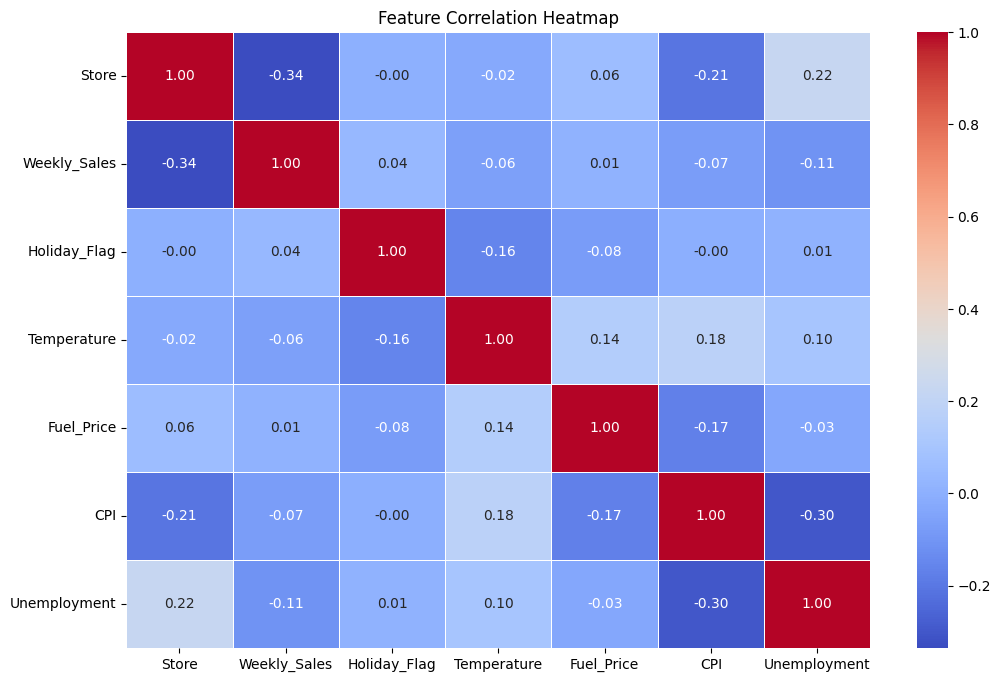

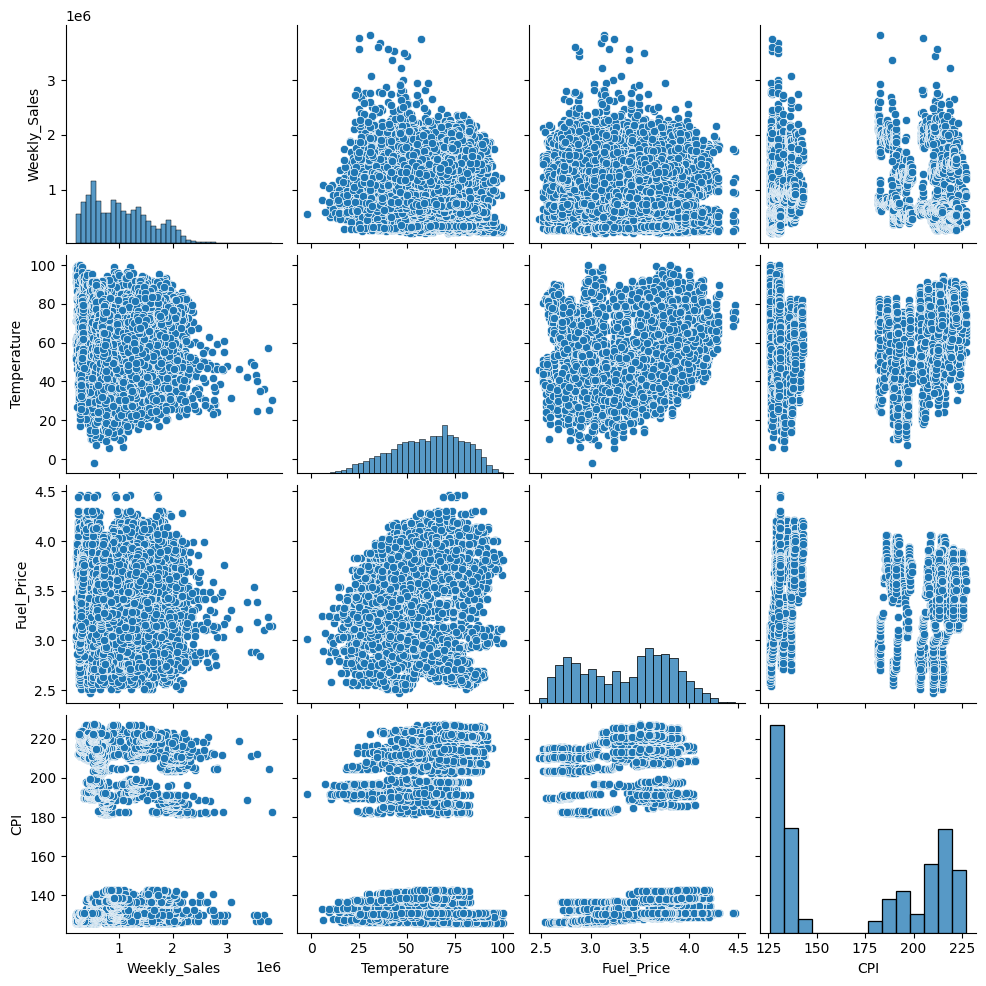

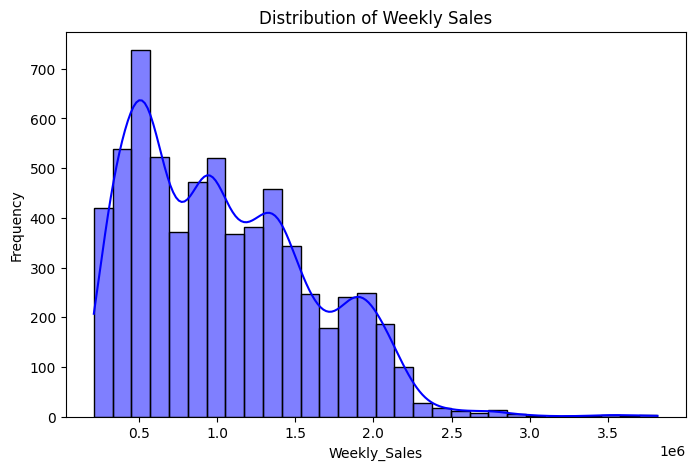

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for numerical type selection

# Load the dataset
df = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

# Correlation heatmap
# Fix: Select only numeric columns for correlation calculation to avoid ValueError with 'Date' column
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Pairplot for key variables
# Fix: Replaced non-existent columns ('rm', 'lstat', 'ptratio', 'medv') with relevant numeric columns from the Walmart dataset
sns.pairplot(df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI']])
plt.show()

# Distribution of target variable (Weekly_Sales)
# Fix: Replaced non-existent 'medv' with 'Weekly_Sales' from the Walmart dataset
plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=30, kde=True, color='blue')
plt.title("Distribution of Weekly Sales") # Updated title for clarity
plt.xlabel("Weekly_Sales") # Updated x-label for clarity
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
# Fix: 'medv' column does not exist. Using 'Weekly_Sales' as the target.
# Also dropping 'Date' as it's a string and not directly usable by LinearRegression.
X = df.drop(columns=["Weekly_Sales", "Date"])  # All columns except target and 'Date'
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R-squared: {r2:.2f}")
print(f"RMSE: {rmse:.2f}")

R-squared: 0.15
RMSE: 523884.74


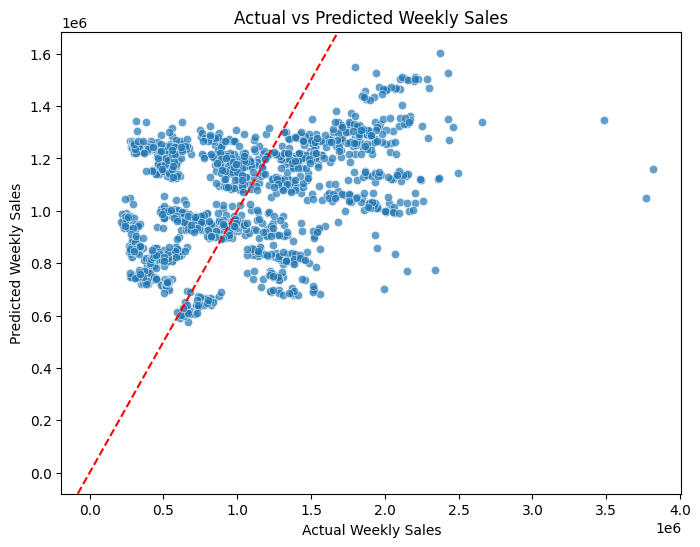

Skewness:
 Store           0.000000
Weekly_Sales    0.668362
Holiday_Flag    3.373499
Temperature    -0.336768
Fuel_Price     -0.096158
CPI             0.063492
Unemployment    1.188144
dtype: float64


<Figure size 1000x2400 with 0 Axes>

<Figure size 1000x2400 with 0 Axes>

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred,alpha=0.7)
plt.xlabel("Actual Weekly Sales") # Fix: Updated label
plt.ylabel("Predicted Weekly Sales") # Fix: Updated label
plt.title("Actual vs Predicted Weekly Sales") # Fix: Updated title
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

skewness = df.select_dtypes(include=np.number).skew() # Fix: Calculate skewness only for numeric columns
print("Skewness:\n", skewness)

# The following lines seem to be part of an incomplete plot; I'll keep them as is for now,
# but you might want to review them if they were intended for a specific visualization.
num_cols = len(df.columns)
plt.figure(figsize=(10, num_cols * 3))

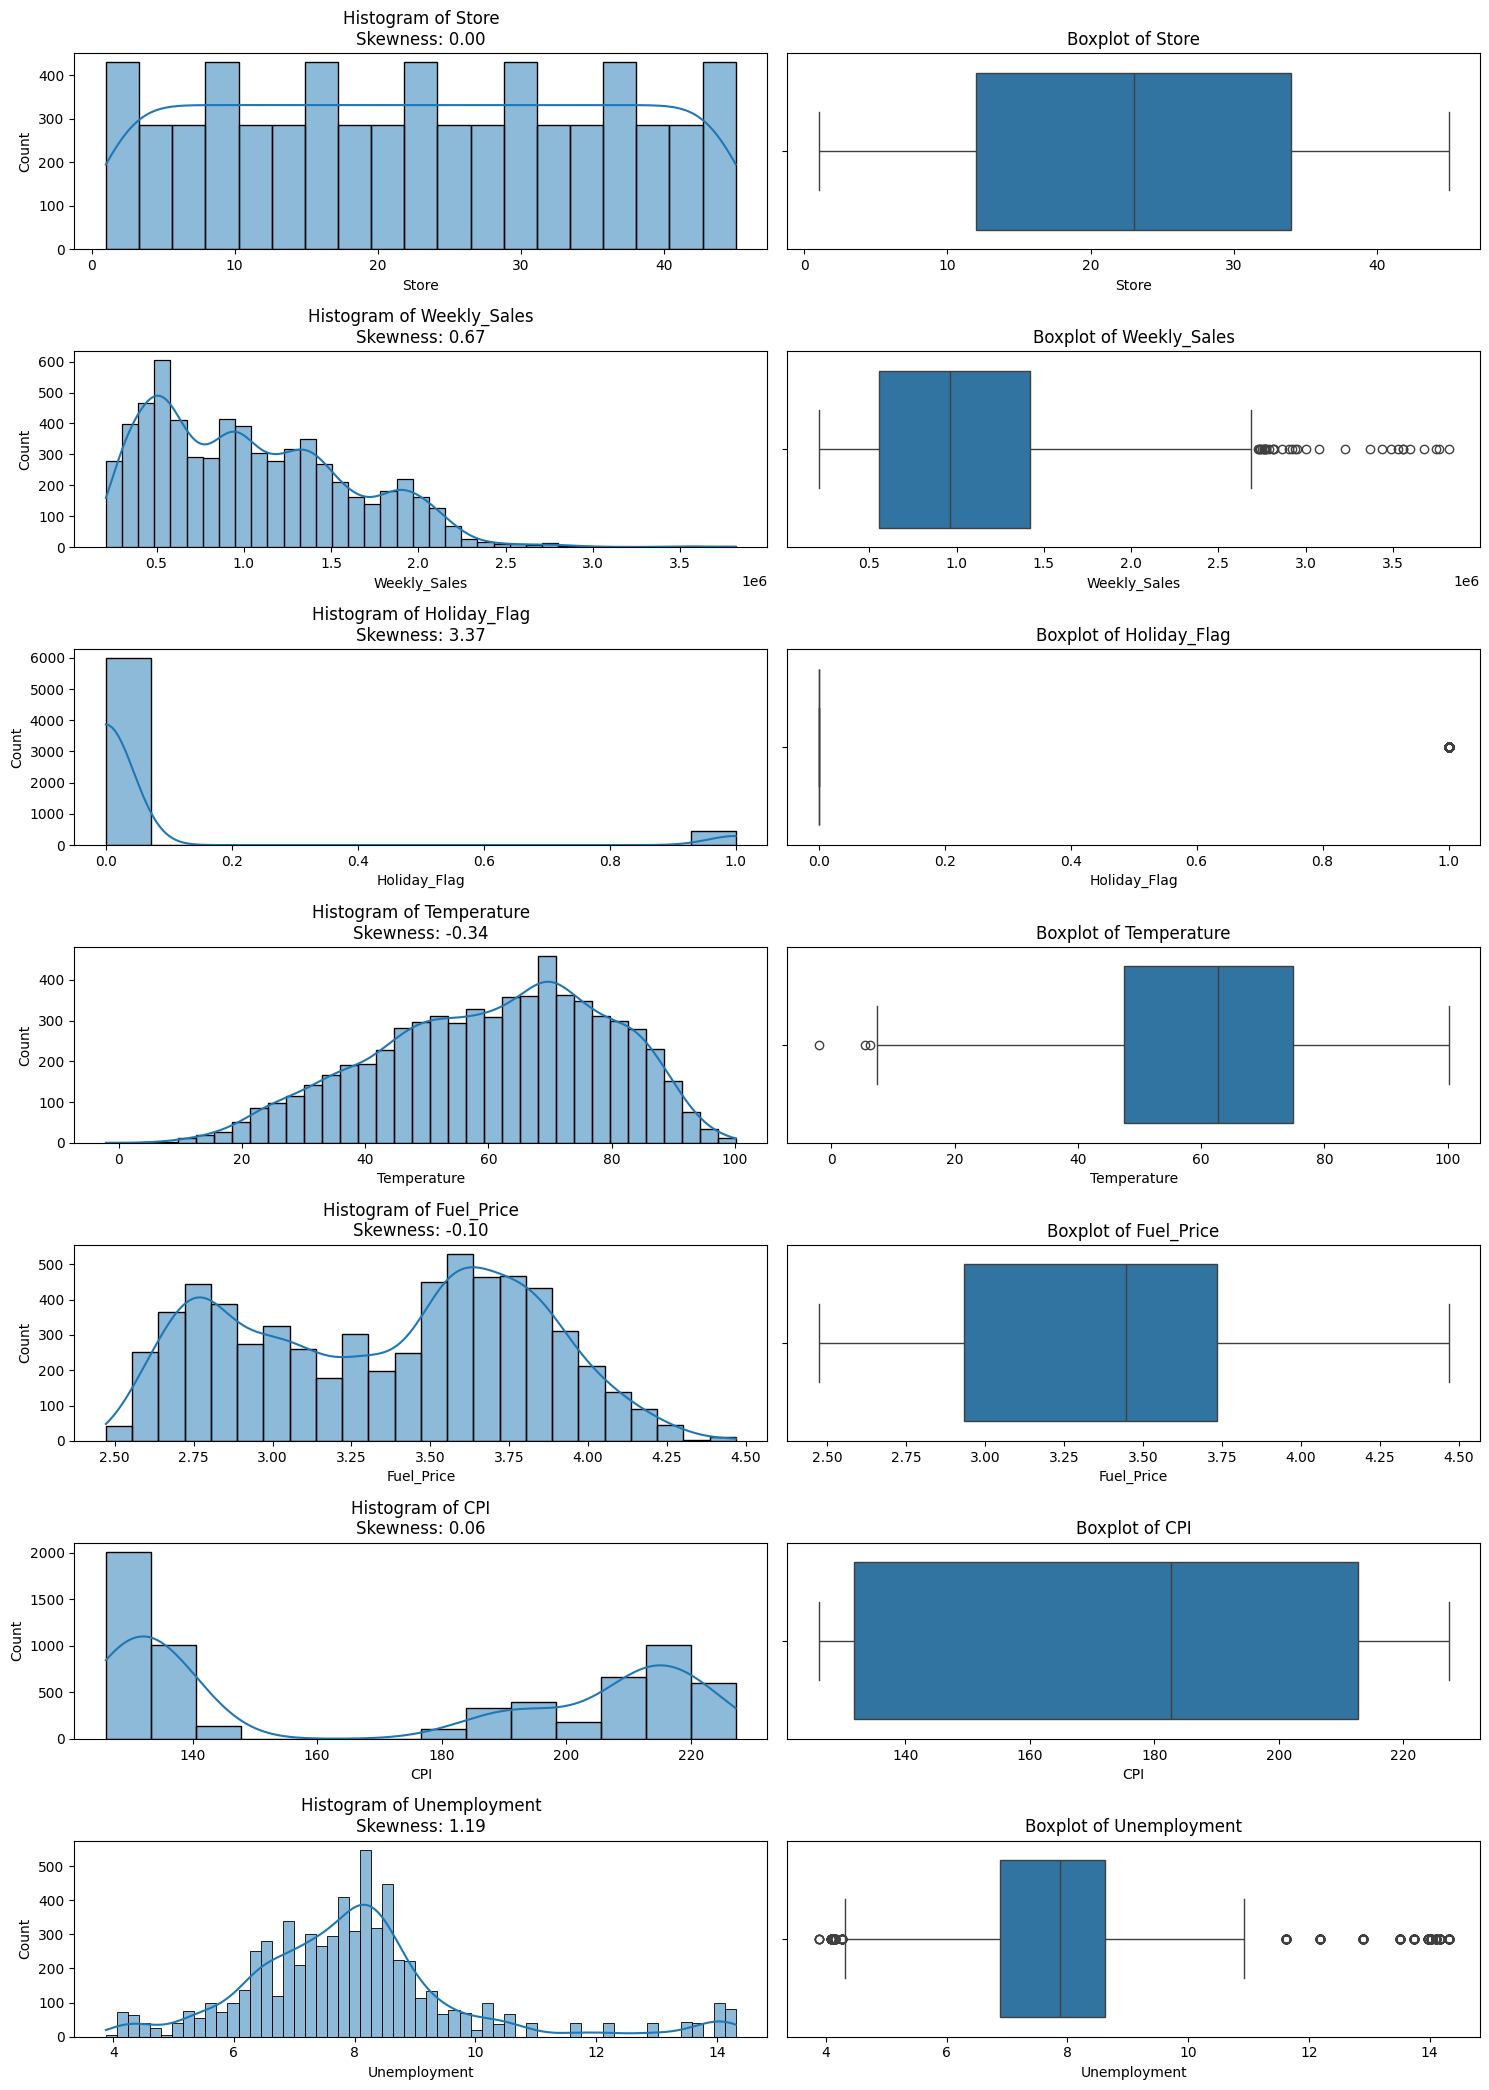

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for numerical type selection

# Select only numeric columns for skewness calculation and plotting
numeric_df = df.select_dtypes(include=np.number)
skewness = numeric_df.skew()

num_cols = len(numeric_df.columns)
plt.figure(figsize=(15, num_cols * 3))

for i, col in enumerate(numeric_df.columns):
  plt.subplot(num_cols, 2, 2 * i + 1)
  sns.histplot(numeric_df[col], kde=True)
  plt.title(f'Histogram of {col}\nSkewness: {skewness[col]:.2f}')

  plt.subplot(num_cols, 2, 2 * i + 2)
  sns.boxplot(x=numeric_df[col])
  plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
skewed_cols = df.select_dtypes(include=np.number).skew().abs()
highly_skewed=skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("highly skewed columns:\n",highly_skewed)
print("negatively skewed columns:\n",negatively_skewed)

highly skewed columns:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')
negatively skewed columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI'], dtype='object')


In [ ]:
df[highly_skewed]=df[highly_skewed].apply(lambda x:np.log1p(x))
print(df[highly_skewed])

      Holiday_Flag  Unemployment
0         0.000000      2.208934
1         0.693147      2.208934
2         0.000000      2.208934
3         0.000000      2.208934
4         0.000000      2.208934
...            ...           ...
6430      0.000000      2.270475
6431      0.000000      2.268718
6432      0.000000      2.268718
6433      0.000000      2.268718
6434      0.000000      2.268718

[6435 rows x 2 columns]


In [ ]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])
df[negatively_skewed]

,Store,Weekly_Sales,Temperature,Fuel_Price,CPI
0,-1.942666,1.062778,-1.017966,-1.683544,1.006528
1,-1.942666,1.060635,-1.204376,-1.732738,1.009450
2,-1.942666,1.023306,-1.135341,-1.802251,1.010391
3,-1.942666,0.757367,-0.799809,-1.706104,1.011002
4,-1.942666,0.950729,-0.806467,-1.574543,1.011613
...,...,...,...,...,...
6430,1.554160,-0.454488,0.186582,1.408278,0.604228
6431,1.554160,-0.408915,0.187148,1.380942,0.607706
6432,1.554160,-0.406671,-0.388228,1.415115,0.611181
6433,1.554160,-0.443275,-0.280200,1.344527,0.611260


In [ ]:
import numpy as np
skewness = df.select_dtypes(include=np.number).skew()
print("Skewness after transformations:\n", skewness)

Skewness after transformations:
 Store          -0.228157
Weekly_Sales   -0.049912
Holiday_Flag    3.373499
Temperature    -0.141684
Fuel_Price     -0.055815
CPI             0.010477
Unemployment    0.226991
dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
# Fix: 'medv' column does not exist. Using 'Weekly_Sales' as the target.
# Also dropping 'Date' as it's a string and not directly usable by LinearRegression.
X = df.drop(columns=["Weekly_Sales", "Date"])  # All columns except target and 'Date'
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R-squared: {r2:.2f}")
print(f"RMSE: {rmse:.2f}")

R-squared: 0.13
RMSE: 0.95


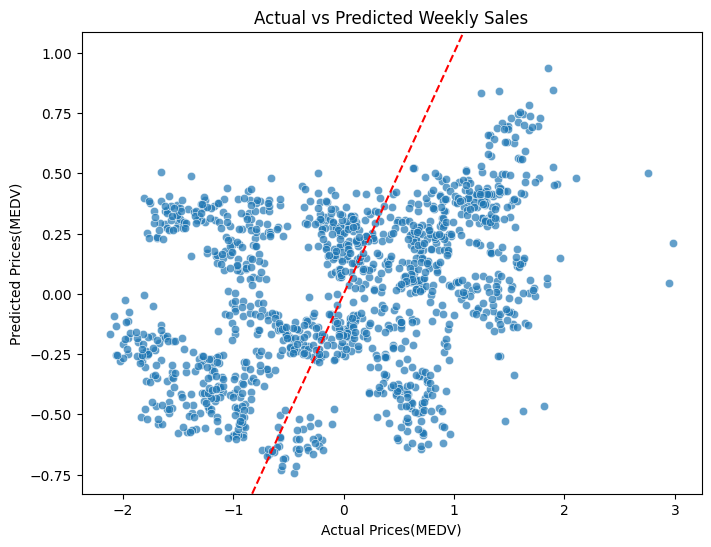

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred,alpha=0.7)
plt.xlabel("Actual Prices(MEDV)")
plt.ylabel("Predicted Prices(MEDV)")
plt.title("Actual vs Predicted Weekly Sales")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)
r2=r2_score(y_test,y_pred)**0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.3563
RMSE: 0.9464
